# Bước 4: Huấn luyện mô hình Random Forest Classifier & Regressor

Notebook này thực hiện huấn luyện mô hình Random Forest trên tệp dữ liệu đã được tiền xử lý.

In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix

print("Imported necessary libraries successfully!")

Imported necessary libraries successfully!


In [2]:
import os
# Tìm đường dẫn tệp processed data bằng cách leo lên các thư mục cha
data_path = 'data/processed/Student_Performance_processed.csv'
for _ in range(5):
    if os.path.exists(data_path):
        break
    data_path = os.path.join('..', data_path)

df_encoded = pd.read_csv(data_path)

# Danh sách đặc trưng khách quan
objective_features = [
    'age', 'study_hours', 'attendance_percentage',
    'parent_education',
    'gender_male', 'gender_female', 'gender_other',
    'travel_time_<15 min', 'travel_time_15-30 min', 'travel_time_30-60 min', 'travel_time_>60 min',
    'study_method_notes', 'study_method_textbook', 'study_method_group study', 
    'study_method_coaching', 'study_method_mixed', 'study_method_online videos'
]

print(f"Loaded processed data with shape: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns.")


Loaded processed data with shape: 25000 rows, 26 columns.


## 3. Các cách tiếp cận huấn luyện mô hình

### Cách 1: Bài toán Hồi quy (Dự đoán điểm tổng kết overall_score)

Chúng ta sẽ dự báo điểm số trung bình liên tục `overall_score` (từ 0 đến 100) của học sinh dựa trên các yếu tố khách quan không dùng điểm thành phần khác.

In [3]:
# Nhãn mục tiêu hồi quy
y_reg = df_encoded['overall_score']
X_reg = df_encoded[objective_features]

# Phân chia Train/Test set
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Huấn luyện Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)

# Đánh giá
y_pred_reg = rf_reg.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("--- REGRESSION EVALUATION RESULTS ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

--- REGRESSION EVALUATION RESULTS ---
Mean Absolute Error (MAE): 4.10
Mean Squared Error (MSE): 24.90
R-squared Score (R2): 0.9314


### Cách 2: Bài toán Phân lớp xếp hạng học lực (Dự đoán nhóm học lực A-F)

Dự báo xếp hạng học lực đa lớp (`final_grade` gồm 6 mức: **A, B, C, D, E, F**) sử dụng các đặc trưng khách quan (không dùng điểm các môn học).

In [4]:
# Nhãn mục tiêu phân lớp
y_clf = df_encoded['final_grade']
X_clf = df_encoded[objective_features]

print("Target grade distribution (final_grade):")
print(y_clf.value_counts().sort_index())

# Phân chia Train/Test set
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Huấn luyện Random Forest Classifier cải tiến với class_weight='balanced'
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
rf_clf.fit(X_train_clf, y_train_clf)

chosen_model = rf_clf

# Đánh giá
y_pred_clf = rf_clf.predict(X_test_clf)
acc = accuracy_score(y_test_clf, y_pred_clf)

print("--- CLASSIFICATION EVALUATION RESULTS ---")
print(f"Accuracy: {acc*100:.2f}%")
print("\nDetailed Classification Report:")
target_labels = sorted(y_clf.unique())
print(classification_report(y_test_clf, y_pred_clf, target_names=target_labels))


Target grade distribution (final_grade):
final_grade
a    1205
b    2696
c    6161
d    6311
e    5672
f    2955
Name: count, dtype: int64
--- CLASSIFICATION EVALUATION RESULTS ---
Accuracy: 76.62%

Detailed Classification Report:
              precision    recall  f1-score   support

           a       0.74      0.81      0.78       256
           b       0.69      0.70      0.70       542
           c       0.78      0.76      0.77      1198
           d       0.77      0.75      0.76      1268
           e       0.78      0.77      0.77      1152
           f       0.80      0.84      0.82       584

    accuracy                           0.77      5000
   macro avg       0.76      0.77      0.77      5000
weighted avg       0.77      0.77      0.77      5000



Top 10 most important features:
1. study_hours (0.5683)
2. attendance_percentage (0.2185)
3. parent_education (0.0512)
4. age (0.0511)
5. travel_time_15-30 min (0.0102)
6. gender_other (0.0101)
7. travel_time_30-60 min (0.0101)
8. travel_time_<15 min (0.0098)
9. travel_time_>60 min (0.0098)
10. gender_male (0.0095)


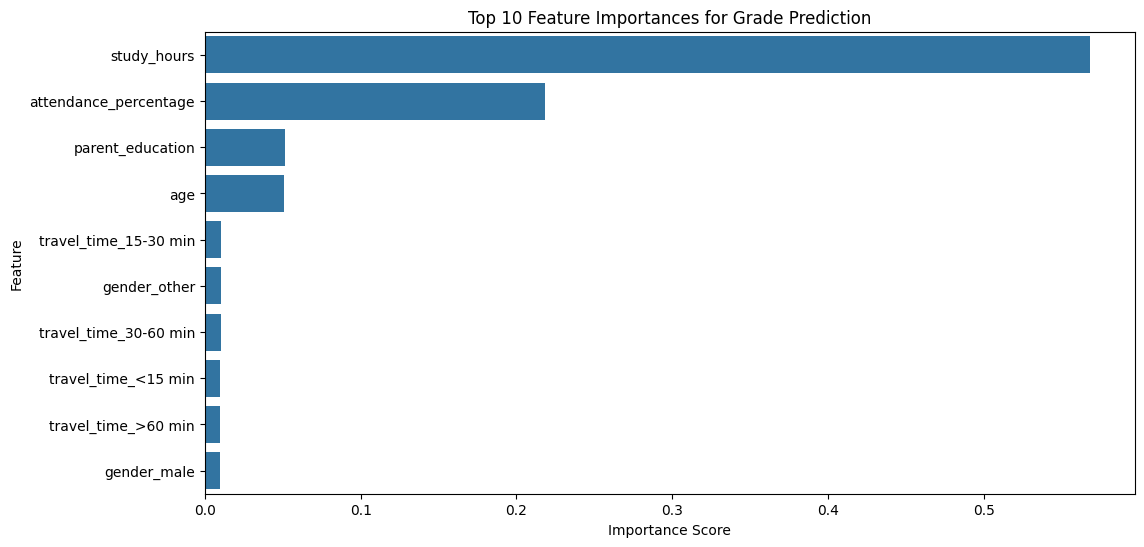

In [5]:
importances = chosen_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 10 most important features:")
for f in range(10):
    print(f"{f + 1}. {objective_features[indices[f]]} ({importances[indices[f]]:.4f})")

# Vẽ biểu đồ cột trực quan
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices[:10]], y=[objective_features[i] for i in indices[:10]])
plt.title('Top 10 Feature Importances for Grade Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()